# OVERVIEW

This notebook serves as examples and analysis of how to use accompanying src .py files

In [1]:
import sys
sys.path.append('../src')
sys.path.append('../../ml_trading_signals/src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#from ml_trading_signals
from features import build_multi_ticker_dataset, build_momentum_equity_curve
from labels import excess_return_target
from walk_forward import walk_forward_momentum_rule

#from this projects src files
from position_sizing import kelly_sizing, kelly_from_returns, volatility_scaled_size 
from risk_limits import compute_drawdown, drawdown_trading_exposure, compute_var, compute_cvar, cvar_constrained_size, combined_position_size, estimate_momentum_turnover, classify_regime, regime_scaled_exposure, correlation_penalty, apply_position_stops
from plotting import plot_equity_drawdown_exposure, plot_position_sizing_comparison, plot_three_way_comparison, plot_all_risk_methods

/Users/oscarlewis/Desktop/python/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
#we use test cases on our 'universe' from ml_trading_signals
tickers = ["AAPL", "MSFT", "GOOGL", "AMZN", "NVDA", "META", "TSLA", "JPM", "JNJ", "XOM", "WMT", "PG", "HD", "DIS", "NFLX", "AMD", "INTC", "CSCO", "ADBE", "CRM"]

pooled = build_multi_ticker_dataset(tickers, period="10y", horizon=21)
pooled_v2 = excess_return_target(pooled, horizon=21)

mom_wf = walk_forward_momentum_rule(pooled_v2, lookback_col='return_21d',top_frac=0.25, train_size=250, test_size=63, embargo=21)

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


AAPL:2292 usable rows


[*********************100%***********************]  1 of 1 completed


MSFT:2292 usable rows


[*********************100%***********************]  1 of 1 completed


...

CSCO:2292 usable rows


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed

ADBE:2292 usable rows


CRM:2292 usable rows


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Begin with kelly-optimal sizing - the fraction of your capital you should invest is given by:

$$
f = \frac{bp - q}{b} = p - \frac{q}{b}
$$
where $p$ is probability of 'winning' (making profit), $q = 1 - p$ and $b$ is payoff ratio. Often assumed $b \approx 1$. This estimate is known to be aggressive, so common for people to use half/quarter of this estimate.

In [3]:
f_theoretical = kelly_sizing(win_prob=0.6571, win_loss_ratio=1.0)
print(f"Theoretical Kelly (p=0.6571, b=1.0): {f_theoretical:.4f}")
print(f"Quarter Kelly:  {kelly_sizing(0.6571, 1.0, frac=0.25):.4f}")
print(f"Half Kelly:     {kelly_sizing(0.6571, 1.0, frac=0.5):.4f}")

f_actual = kelly_from_returns(mom_wf['excess'], frac=1.0)
print(f"\nKelly from actual fold returns: {f_actual:.4f}")
print(f"Recommended (quarter Kelly): {f_actual * 0.25:.4f}")

Theoretical Kelly (p=0.6571, b=1.0): 0.3142
Quarter Kelly:  0.0786
Half Kelly:     0.1571

Kelly from actual fold returns: 0.4177
Recommended (quarter Kelly): 0.1044


Clear difference in our estimates. The win-probs of 65.71% comes from ml_trading_signals, where 65.71% of folds returned positive returns under that walk forward. We believe this is due to our estimation of each win and loss being approximately the same size ($b \approx 1$). This is tested below

In [4]:
wins = mom_wf['excess'][mom_wf['excess'] > 0]
losses = mom_wf['excess'][mom_wf['excess'] < 0]

print(f"Number of winning folds: {len(wins)}")
print(f"Number of losing folds:  {len(losses)}")
print(f"Mean win:  {wins.mean()*100:.4f}%")
print(f"Mean loss: {losses.mean()*100:.4f}%")
print(f"Actual win/loss ratio (b): {wins.mean() / abs(losses.mean()):.4f}")

Number of winning folds: 20
Number of losing folds:  14
Mean win:  0.6734%
Mean loss: -0.2788%
Actual win/loss ratio (b): 2.4151


The reason for these estimates is now clear, that each win is near over twice an average loss. We take the actual quarter-kelly value as our baseline for the following testing (11%).

In [5]:
sys.path.append('../../time_series_forecasting/src')
from garch_model import fit_garch, forecast_volatility


ticker_returns = pooled_v2[pooled_v2['ticker'] == 'AAPL'].sort_index()
close_returns = ticker_returns['return_1d'].dropna()

trailing_vol = close_returns.rolling(63).std().iloc[-1] * np.sqrt(252)

garch_fitted = fit_garch(close_returns)
garch_vol = forecast_volatility(garch_fitted, horizon=1)[0]

print(f"Trailing 63-day realised vol: {trailing_vol:.4f}")
print(f"GARCH day-1 forecast:         {garch_vol:.4f}")

size_trailing = volatility_scaled_size(target_risk=0.02, asset_vol=trailing_vol)
size_garch = volatility_scaled_size(target_risk=0.02, asset_vol=garch_vol)

print(f"\nPosition size (trailing vol): {size_trailing:.4f}")
print(f"Position size (GARCH):        {size_garch:.4f}")

Trailing 63-day realised vol: 0.3160
GARCH day-1 forecast:         0.2686

Position size (trailing vol): 0.0633
Position size (GARCH):        0.0745


Now turn our attention to circuit breakers. The momentum model from ml_trading_signals is adjusted slightly to make an equity curve, where the tickers chosen are due to that rule and rebalanced every 63 days. We implemented soft, hard limits based on the maximum drawdown of this method at 10%, 25% (when the max drawdown is below -10%, our exposure to the market decreases linearly from 1 until 0 (at 25%)). Intended to turn terrible losses into manageable ones. This is tested over the past 10 years with the plot below of the equity, max drawdown and exposure telling the story.

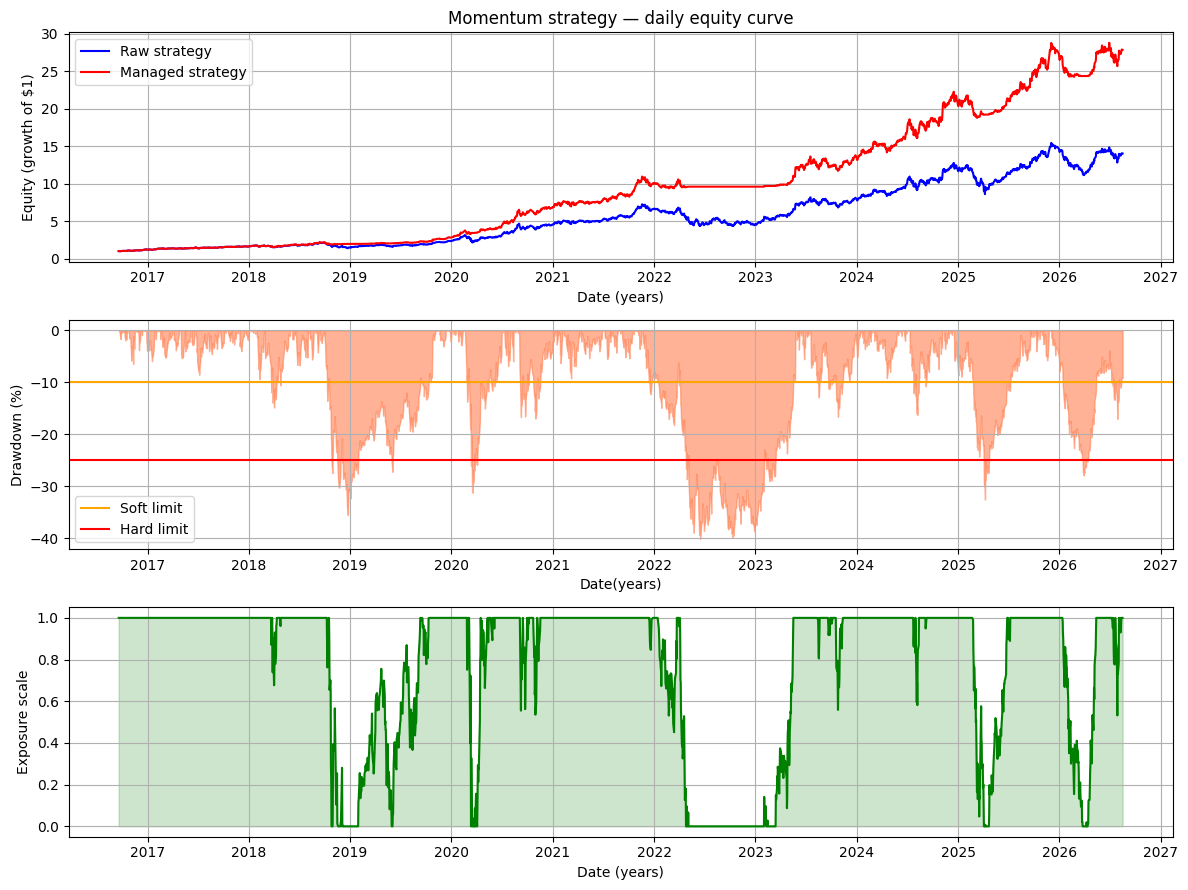

In [6]:
daily_equity = build_momentum_equity_curve(pooled_v2)
daily_dd = compute_drawdown(daily_equity['equity'])
daily_exposure = drawdown_trading_exposure(daily_dd, soft_limit=-0.10, hard_limit=-0.25)

managed_returns = daily_equity['portfolio_return'] * daily_exposure
managed_equity = (1 + managed_returns).cumprod()
managed_dd = compute_drawdown(managed_equity)

plot_equity_drawdown_exposure(daily_equity, managed_equity, daily_dd, daily_exposure)

We see the design is working correctly - periods of high max drawdown lead to periods of low - minimal exposure. Looking at the managed equity at these times, as expected, when the max drawdown is above -10% the strategies are the same, the difference comes in turbulent periods, where at every single one the managed strategy outperforms, ending up ~2x better off over the 10-year period. This is due to the raw strategy trading entirely through bad periods, where we tend to lose and have more volatility, whereas the managed strategy trades more methodically and with limited capital, leading to better returns over the long haul. We get specific stats for reference below.

In [18]:

print(f"Percentage of time in reduced-exposure state: {(daily_exposure < 1.0).mean()*100:.2f}%")
print(f"Maximum Drawdown of Raw Strategy: {daily_dd.min() * 100:.4f}%")
print(f"Maximum Drawdown of Managed Strategy: {managed_dd.min() * 100:.4f}%")
print(f"Raw final equity:     {daily_equity['equity'].iloc[-1]:.2f}")
print(f"Managed final equity: {managed_equity.iloc[-1]:.2f}")

Percentage of time in reduced-exposure state: 36.85%
Maximum Drawdown of Raw Strategy: -40.0924%
Maximum Drawdown of Managed Strategy: -15.7648%
Raw final equity:     14.04
Managed final equity: 27.88


The intuition from the plot was correct, we end up with near enough perfectly double the returns using our given risk management approach, showing the value of having one. We see that we fall into the state for our risk management 32.57% of the time, and trading 'better' in that period of time is what makes us 2x more over 10 years. 

Now move on to VaR (value at risk) and CVaR (conditional value at risk). This is a function of a confidence level, x%. if VaR(x%) = -y%, then on x% of days we don't lose more than y%. If CVaR(x%) = -z%, then, given we're in the (100 - x) percentile, what is the expected loss? A common confidence level is 95%, which is what is implemented below.

In [8]:
rets = daily_equity['portfolio_return']
print(f"VaR (95%):  {compute_var(rets)*100:.4f}%")
print(f"CVaR (95%): {compute_cvar(rets)*100:.4f}%")
print(f"Ratio (CVaR/VaR): {compute_cvar(rets)/compute_var(rets):.3f}")
print(f"\nCVaR-constrained size (3% budget): {cvar_constrained_size(rets, -0.03):.4f}")

VaR (95%):  -2.6768%
CVaR (95%): -4.0745%
Ratio (CVaR/VaR): 1.522

CVaR-constrained size (3% budget): 0.7363


CVaR constrained size is so that our size is limited to ensure that our position lays below our CVaR budget. Here we restrict our CVaR budget to -3% (don't allow a size which leaves the position with less than -3% CVaR), and hence the size is scaled down (since CVaR(95%) < -3%). Also notice, we lose more than ~2.5% on 95% of days, but if we are on one of those days, we expect to lose ~3.77%, showing how CVaR can be a more useful metric for measuring troughs in the market.

Now compose the 3 main methods of sizing into one. Aim to satisfy all 3 at once, as this intuitively means the approach is the safest.

In [9]:
final_size = combined_position_size(
    kelly_size=f_actual * 0.25,      #quarter Kelly from earlier
    vol_scaled_size=size_garch,       #GARCH from volatility scaling
    cvar_size=cvar_constrained_size(rets, cvar_budget=-0.03) #CVaR above
)
print(f"Kelly (quarter):      {f_actual*0.25:.4f}")
print(f"Volatility-scaled:    {size_garch:.4f}")
print(f"CVaR-constrained:     {cvar_constrained_size(rets, -0.03):.4f}")
print(f"\nFinal recommended size (min of all three): {final_size:.4f}")

Kelly (quarter):      0.1044
Volatility-scaled:    0.0745
CVaR-constrained:     0.7363

Final recommended size (min of all three): 0.0745


Now plot to see which sizing methods are taking priority

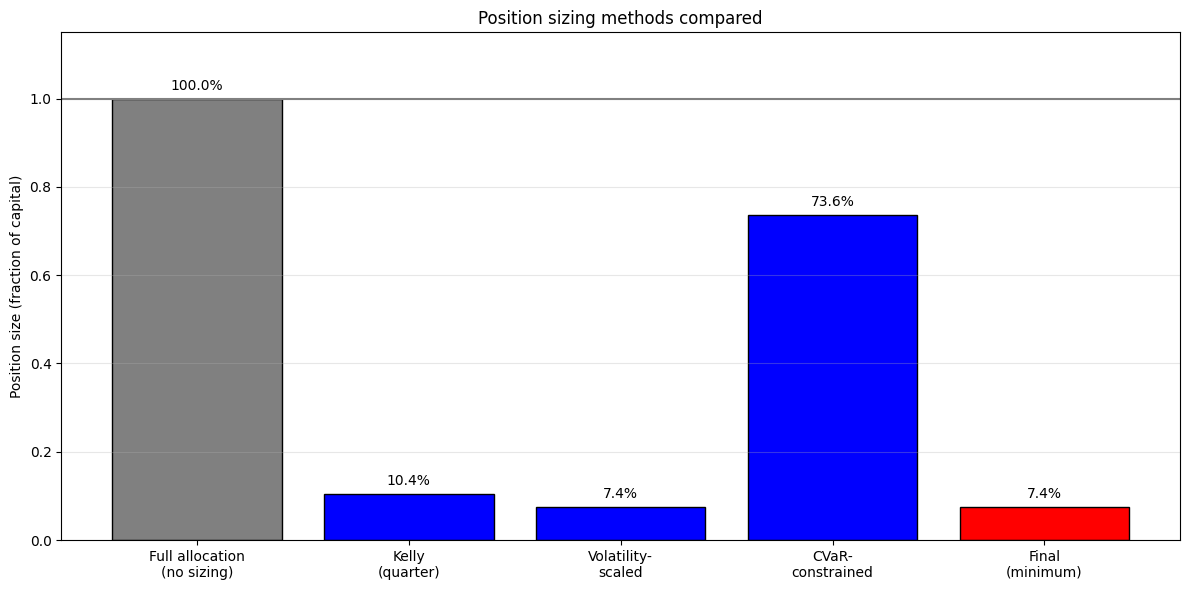

In [10]:
plot_position_sizing_comparison(f_actual*0.25, size_garch, cvar_constrained_size(rets, cvar_budget=-0.03), final_size)

From the plot, it is clear that satisfying the CVaR requirement is not difficult at all, the other 2 methods is where it becomes a factor.

Now move on to modelling transaction costs. Saw earlier that the managed strategy outperformed the raw strategy by ~2x, but this did not include modelling costs. We look at these effects here.

In [11]:
turnover_events = estimate_momentum_turnover(pooled_v2, rebalance_days=63)
print(f"\nMean turnover per rebalance: {turnover_events['turnover'].mean()*100:.1f}%")

avg_daily_cost_drag = (turnover_events['turnover'].mean() * (10/10000)) / 63
managed_returns_net = managed_returns - avg_daily_cost_drag
managed_equity_net = (1 + managed_returns_net).cumprod()

print(f"\nManaged equity, gross: {managed_equity.iloc[-1]:.2f}")
print(f"Managed equity, net of costs: {managed_equity_net.iloc[-1]:.2f}")


Mean turnover per rebalance: 71.8%

Managed equity, gross: 27.88
Managed equity, net of costs: 27.10


This seems good on the surface, but it could be that this process is unstable, and as the costs are increasing from 0.1% to 1%, it could become catastrophic. This stability is tested below.

In [12]:
for cost_bps in [5, 10, 25, 50, 100]:
    drag = (turnover_events['turnover'].mean() * (cost_bps/10000)) / 63
    net_returns = managed_returns - drag
    net_equity = (1 + net_returns).cumprod()
    print(f"Cost {cost_bps}bps: final equity = {net_equity.iloc[-1]:.2f}")

Cost 5bps: final equity = 27.48
Cost 10bps: final equity = 27.10
Cost 25bps: final equity = 25.97
Cost 50bps: final equity = 24.19
Cost 100bps: final equity = 20.99


See a stability in this process. As expected, higher transaction costs mean more equity loss, but it is at a rate which makes sense. Even with 1% transaction costs applied quarterly, our managed approach outperforms the raw momentum approach by ~50%. 

Try a regime approach, where exposure is scaled down during periods of high volatility. Intuitively (and historically) momentum approaches tend to struggle in volatile times, so try this approach. Notice that this includes periods of high-upswing too, so potentially lose out there.

In [13]:
regime, rolling_vol = classify_regime(daily_equity['portfolio_return'])
regime_exposure = regime_scaled_exposure(rolling_vol)

print(f"Days in high-vol regime: {(regime=='high_vol').sum()} / {len(regime)}")
print(f"Days with reduced regime exposure: {(regime_exposure < 1.0).sum()}")

regime_managed_returns = daily_equity['portfolio_return'] * regime_exposure
regime_managed_equity = (1 + regime_managed_returns).cumprod()
regime_dd = compute_drawdown(regime_managed_equity)

print(f"\nRegime-managed max drawdown: {regime_dd.min()*100:.2f}%")
print(f"Regime-managed final equity: {regime_managed_equity.iloc[-1]:.2f}")

Days in high-vol regime: 627 / 2491
Days with reduced regime exposure: 2222

Regime-managed max drawdown: -23.30%
Regime-managed final equity: 7.33


Results don't look too good on the surface, which isn't too suprising as volatility is a price-neutral metric. It doesn't tell us whether the price is increasing or decreasing. Max drawdown tells us that the results are decreasing from a peak, so its only high (negatively) when the tickers price is reducing. The plot below gives more insight

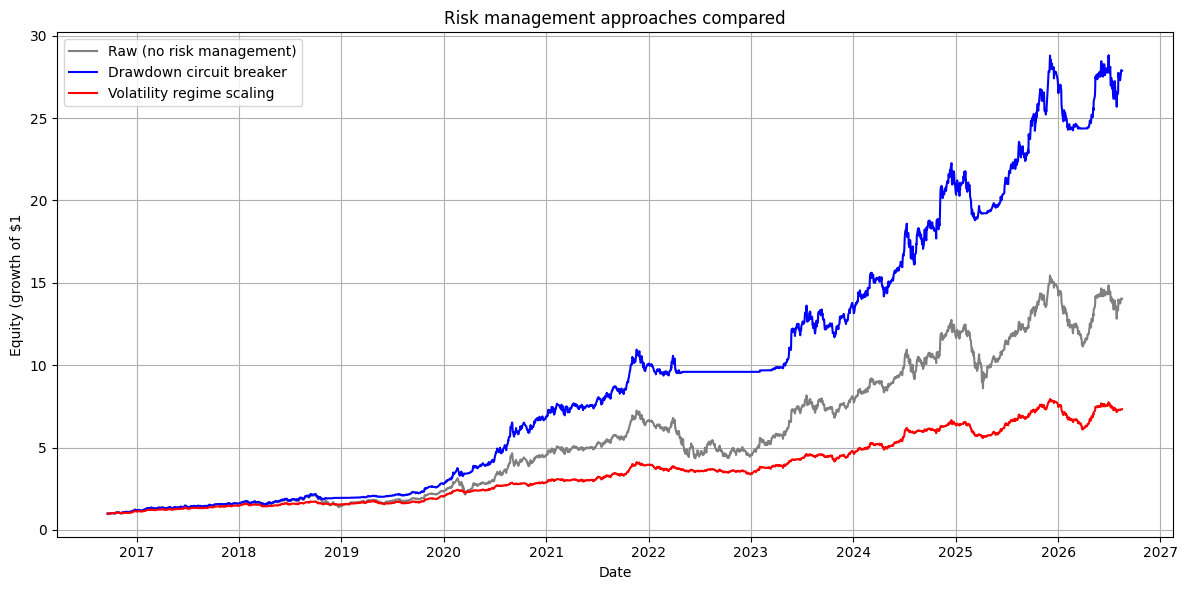

In [14]:
plot_three_way_comparison(daily_equity['equity'], managed_equity, regime_managed_equity)

Sometimes, tickers can have high correlation between them, so when things go bad, they go really bad. We test for this below.

In [15]:
sample_date = sorted(pooled_v2.dropna(subset=['return_21d']).index.unique())[500]
day = pooled_v2.loc[pooled_v2.index == sample_date].dropna(subset=['return_21d'])
day = day.sort_values('return_21d', ascending=False)
selection = set(day.head(5)['ticker'])

print(f"Selected basket: {selection}")

penalty_scale, avg_corr = correlation_penalty(pooled_v2, selection)
print(f"Average pairwise correlation: {avg_corr:.4f}")
print(f"Exposure scale from correlation: {penalty_scale:.4f}")

Selected basket: {'AAPL', 'JNJ', 'NFLX', 'AMD', 'HD'}
Average pairwise correlation: 0.0134
Exposure scale from correlation: 0.9933


See that the correlation over time is very minimal over time, so no reason to implement this in more detail as effects will be minimal from raw strategy.

The last strategy tested here is a stop-loss approach. Think of the triple-labels approach from ml_trading_signals, trading ceases when the ticker hits the profit multiplier or the stop multiplier. The capital remains until the next 

In [16]:
stopped_equity = apply_position_stops(tickers, stop_mult=1.0, profit_mult=2.0, rebalance_days=63)

stopped_dd = compute_drawdown(stopped_equity['equity'])

print(f"No stops — final equity: {daily_equity['equity'].iloc[-1]:.2f}, "
      f"max drawdown: {compute_drawdown(daily_equity['equity']).min()*100:.2f}%")
print(f"With stops — final equity: {stopped_equity['equity'].iloc[-1]:.2f}, "
      f"max drawdown: {stopped_dd.min()*100:.2f}%")

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

No stops — final equity: 14.04, max drawdown: -40.09%
With stops — final equity: 2.77, max drawdown: -21.19%


The approach here also performs poorly, despite having a low max drawdown. Results could change drastically based on the changing of rebalancing, but this is left for future exploration. We have a plot to compare all approaches encountered in this project.

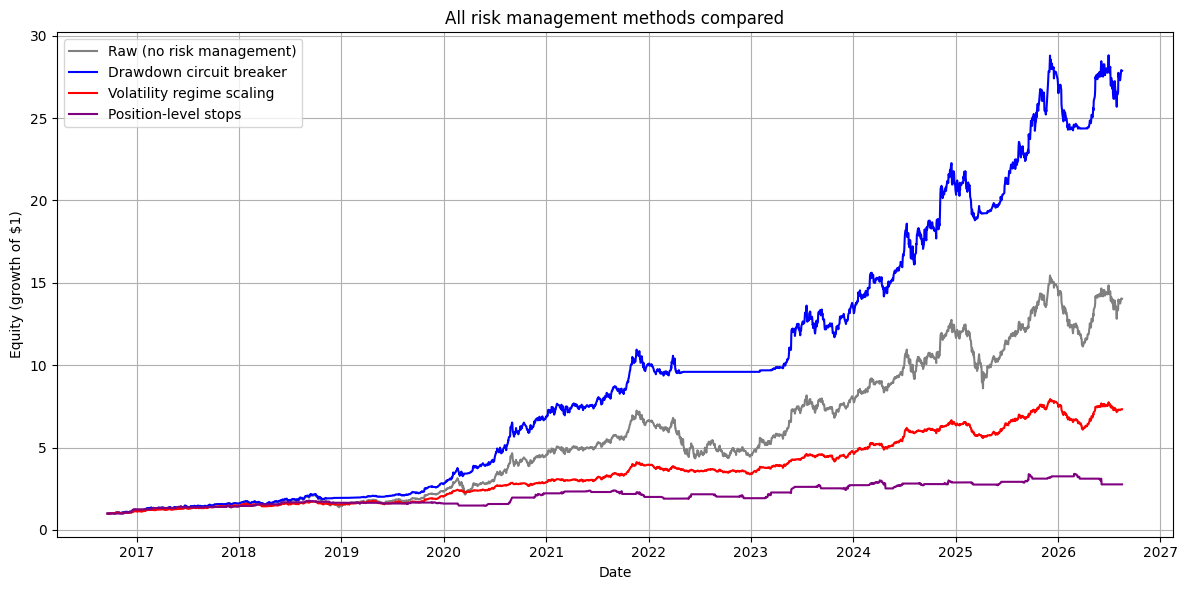

In [17]:
plot_all_risk_methods(daily_equity['equity'], managed_equity, regime_managed_equity, stopped_equity['equity'])

There is a function included in here called 'final_risk_policy' which combines the two main approaches (sizes by final_size), then implements the circuit breaker risk mechanism. This only includes ~7.5% of somebodies portfolio, so does not suit to plot on the above. Much better to be used as a part of a bigger puzzle.